In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from datetime import datetime

from multiclass_Classification_2 import *
DEVICE = "mps" if torch.mps.is_available() else "cpu"

In [2]:
timestamp = datetime.now().strftime("%m%d_%H%M")
BATCH_SIZE = 32
LR = 1e-3
LR_STEP = 3
LR_GAMMA = 0.9
EPOCH = 5
TRAIN_RATIO = 0.8
criterion = nn.CrossEntropyLoss()
new_model_train = True
model_type = "CNN_deep"
dataset = "STL10"
save_model_path = f'/Volumes/김상현/results/{model_type}_{dataset}_{timestamp}.pt'
save_history_path = f'/Volumes/김상현/results/{model_type}_history_{dataset}_{timestamp}.pt'

In [3]:
transform = transforms.ToTensor()
train_DS = datasets.STL10(root = '/Volumes/김상현/dataset', split = "train", download = False, transform = transform)

# train data에 일부를 val data set으로 설정하는 작업
NoT = int(len(train_DS) * TRAIN_RATIO)
NoV = len(train_DS) - NoT
train_DS, val_DS = torch.utils.data.random_split(train_DS, [NoT, NoV])
test_DS = datasets.STL10(root = '/Volumes/김상현/dataset', split = "test", download = False, transform = transform)

# Batch_size에 맞게 데이터 load
train_DL = torch.utils.data.DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
val_DL = torch.utils.data.DataLoader(val_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

In [4]:
class CNN_deep(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block1 = nn.Sequential(nn.Conv2d(3,32,3,padding=1),
                                         nn.BatchNorm2d(32),
                                         nn.ReLU(),
                                         nn.Conv2d(32,32,3,padding=1),
                                         nn.BatchNorm2d(32),
                                         nn.ReLU())
        self.Maxpool1 = nn.MaxPool2d(2)

        self.conv_block2 = nn.Sequential(nn.Conv2d(32,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU(),
                                         nn.Conv2d(64,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU(),
                                         nn.Conv2d(64,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU())
        self.Maxpool2 = nn.MaxPool2d(2)

        self.conv_block3 = nn.Sequential(nn.Conv2d(64,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU(),
                                         nn.Conv2d(128,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU(),
                                         nn.Conv2d(128,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU())
        self.Maxpool3 = nn.MaxPool2d(2)
        
        # self.classifier = nn.Sequential(nn.Linear(128*4*4,512),
        #                                 nn.Linear(512,10))
        self.classifier = nn.Sequential(nn.Linear(128*12*12,512),
                                        nn.Linear(512,10))    
        
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.Maxpool1(x)
        x = self.conv_block2(x)
        x = self.Maxpool2(x)
        x = self.conv_block3(x)
        x = self.Maxpool3(x)
        # x = torch.flatten(x, start_dim=1) # !!!!!!!
        # x = self.classifier(x)
        x = torch.flatten(x, start_dim=1) # !!!!!!!
        x = self.classifier(x)
        return x

In [5]:
exec(f"model = {model_type}().to(DEVICE)")
print(model)
x_batch, _ = next(iter(train_DL))
print(model(x_batch.to(DEVICE)).shape)

CNN_deep(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (Maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=

Epoch: 1, current_LR = 0.001


100%|██████████| 32/32 [00:00<00:00, 65.88it/s]


train loss: 7.6384, val loss: 2.42926 
train acc: 16.8 %, val acc: 23.4 %, time: 7 s
--------------------
Epoch: 2, current_LR = 0.001


100%|██████████| 32/32 [00:00<00:00, 71.75it/s]


train loss: 2.02432, val loss: 1.87808 
train acc: 30.3 %, val acc: 38.9 %, time: 7 s
--------------------
Epoch: 3, current_LR = 0.001


...

train loss: 1.66635, val loss: 1.63841 
train acc: 40.9 %, val acc: 38.4 %, time: 7 s
--------------------
Epoch: 4, current_LR = 0.001


100%|██████████| 32/32 [00:00<00:00, 70.55it/s]


train loss: 1.50066, val loss: 1.42237 
train acc: 44.8 %, val acc: 47.0 %, time: 7 s
--------------------
Epoch: 5, current_LR = 0.001


100%|██████████| 32/32 [00:00<00:00, 71.87it/s]


train loss: 1.34259, val loss: 1.68011 
train acc: 51.4 %, val acc: 39.2 %, time: 6 s
--------------------


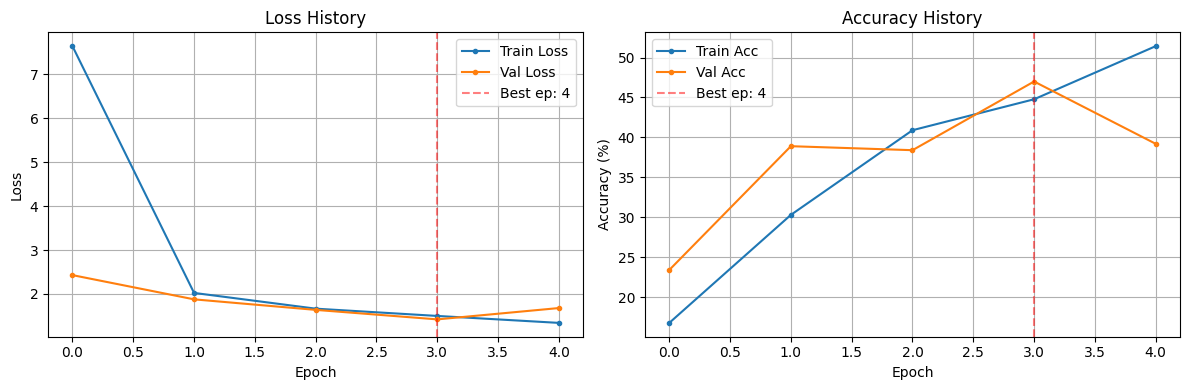

Best Val Loss: 1.42237 @ Epoch 4


In [6]:
if new_model_train:
    optimizer = optim.Adam(model.parameters(), lr = LR)
    loss_history, acc_history = Train(model, train_DL, val_DL, criterion, optimizer, 
          EPOCH, BATCH_SIZE, TRAIN_RATIO,
          save_model_path, save_history_path)
    
    torch.save(model, save_model_path)
    plot_history(loss_history, acc_history)
    
    

In [23]:
load_model = torch.load(save_model_path, map_location=DEVICE, weights_only=False)

In [24]:
Test(load_model ,test_DL, criterion)
print(count_params(load_model))

100%|██████████| 250/250 [00:03<00:00, 68.42it/s]


Test loss: 1.53501
Test accuracy: 3639/8000 (45.5 %)
9915626


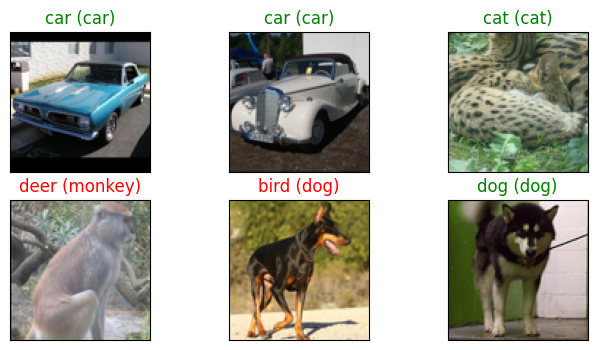

In [20]:
Test_plot(load_model, test_DL)